**Problem Statement**

Behavioral Segmentation for Targeted Marketing
Statement:

Businesses group customers based on purchasing power to tailor marketing
efforts. Students will generate a 150-row retail dataset featuring Annual_Spending and
Purchase_Frequency. The project involves StandardScaler and the K-Means Clustering
algorithm to identify customer "personas."
Pipeline: Retail Data Synthesis --> StandardScaler --> K-Means --> Elbow Method
Visualization.

---

1. **Import libraries**

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

---

2. **Loading DataSet**



In [63]:
df=pd.read_csv("dataset.csv")
df.head()

,Customer_ID,Gender,City,City_Tier,Annual_Income,Annual_Spending,Purchase_Frequency
0,1,Male,Chennai,1.0,4.137690e+06,1.215936e+06,38.937976
1,2,Male,Jabalpur,3.0,9.319119e+05,1.935790e+05,25.171201
2,3,Male,Lucknow,2.0,6.188340e+05,1.168110e+05,39.112999
3,4,Male,Chandigarh,2.0,7.148351e+05,2.307010e+05,22.990749
4,5,Male,Jaipur,2.0,6.967691e+05,2.603871e+05,24.054294


---

3. **Start of EDA**

In [64]:
df.isna().sum()

,0
Customer_ID,0
Gender,0
City,19
City_Tier,17
Annual_Income,17
Annual_Spending,16
Purchase_Frequency,17


- Fill NA Values

In [65]:
df=df.fillna({"Annual_Income":df['Annual_Income'].mean(),"Annual_Spending":df['Annual_Spending'].mean(),"Purchase_Frequency":df['Purchase_Frequency'].mean()})

- Drop not necessary features

In [66]:
df_model=df.drop(columns=["City","City_Tier","Customer_ID","Gender"])
df_model.isna().sum()

,0
Annual_Income,0
Annual_Spending,0
Purchase_Frequency,0


In [67]:
df_model.head()

,Annual_Income,Annual_Spending,Purchase_Frequency
0,4.137690e+06,1.215936e+06,38.937976
1,9.319119e+05,1.935790e+05,25.171201
2,6.188340e+05,1.168110e+05,39.112999
3,7.148351e+05,2.307010e+05,22.990749
4,6.967691e+05,2.603871e+05,24.054294


In [68]:
df_model.info()
df_model.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Annual_Income       285 non-null    float64
 1   Annual_Spending     285 non-null    float64
 2   Purchase_Frequency  285 non-null    float64
dtypes: float64(3)
memory usage: 6.8 KB


,Annual_Income,Annual_Spending,Purchase_Frequency
count,2.850000e+02,2.850000e+02,285.000000
mean,2.191237e+06,6.063367e+05,35.391780
std,1.976993e+06,5.408068e+05,18.981814
min,2.500149e+05,6.104098e+04,4.876134
25%,8.246741e+05,2.307010e+05,23.014434
50%,1.631565e+06,4.657309e+05,32.879968
75%,2.448260e+06,7.649111e+05,42.913025
max,1.039397e+07,2.969988e+06,110.235708


- Outlier Detection

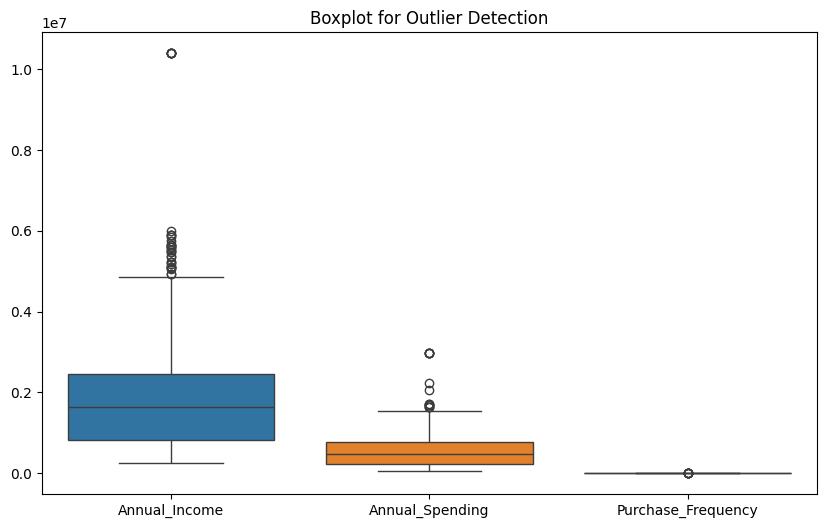

In [69]:
plt.figure(figsize=(10,6))
sb.boxplot(data=df_model)
plt.title("Boxplot for Outlier Detection")
plt.show()

**Apply log transformation**

In [70]:
df_model['Annual_Income'] = np.log1p(df_model['Annual_Income'])
df_model['Annual_Spending'] = np.log1p(df_model['Annual_Spending'])
df_model['Purchase_Frequency'] = np.log1p(df_model['Purchase_Frequency'])

**Check Effectiveness of log transform**

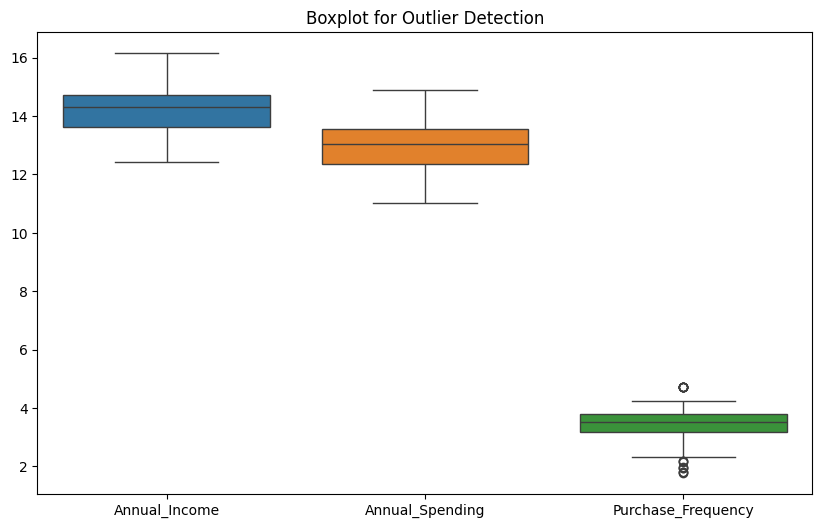

In [71]:
plt.figure(figsize=(10,6))
sb.boxplot(data=df_model)
plt.title("Boxplot for Outlier Detection")
plt.show()

array([[<Axes: title={'center': 'Annual_Income'}>,
        <Axes: title={'center': 'Annual_Spending'}>],
       [<Axes: title={'center': 'Purchase_Frequency'}>, <Axes: >]],
      dtype=object)

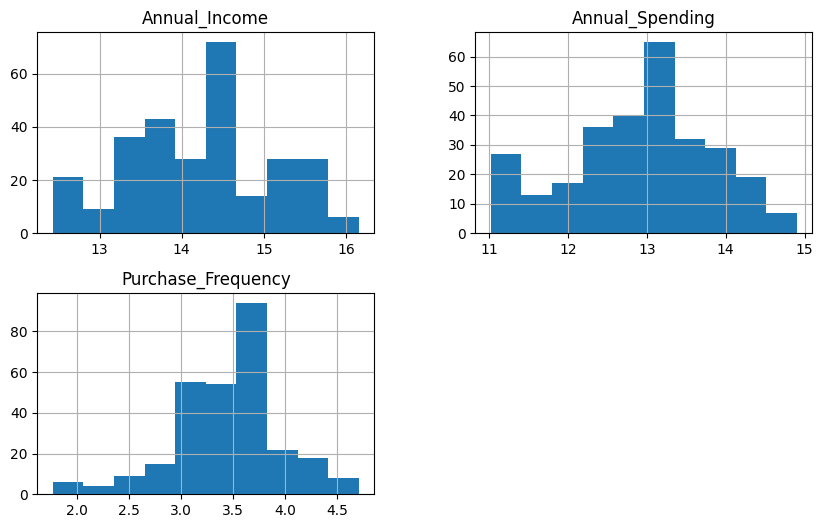

In [72]:
df_model.hist(figsize=(10,6))

- Outlier removal

In [73]:
for col in ['Annual_Income','Annual_Spending','Purchase_Frequency']:
    q1=df_model[col].quantile(0.25)
    q3=df_model[col].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    df_model=df_model[(df_model[col]>=lower) & (df_model[col]<=upper)]

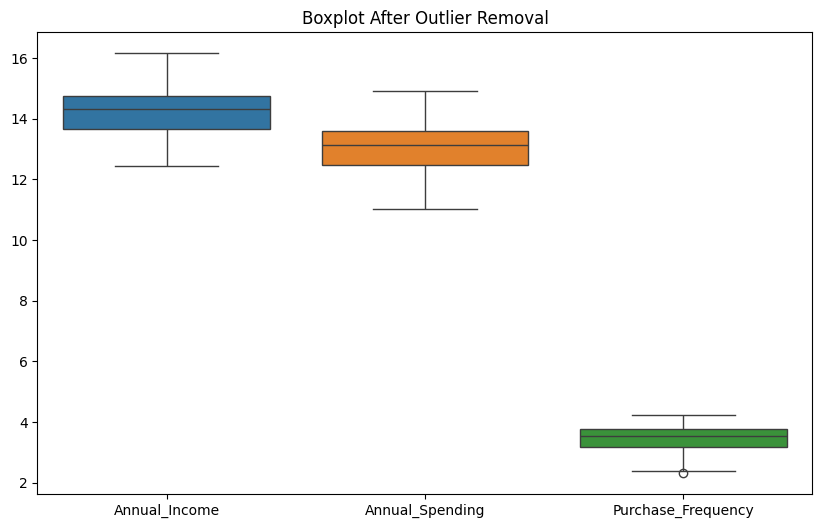

In [74]:
plt.figure(figsize=(10,6))
sb.boxplot(data=df_model)
plt.title("Boxplot After Outlier Removal")
plt.show()

**Correlation**

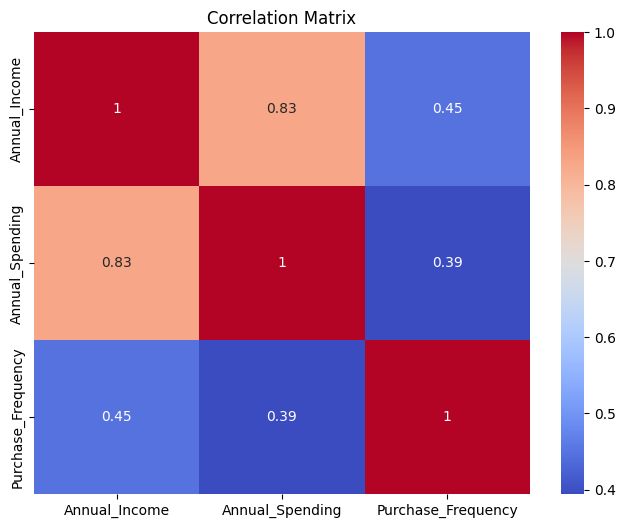

In [75]:
plt.figure(figsize=(8,6))
sb.heatmap(df_model.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

- Correlation matrix shows low multicollinearity, making features suitable for K-Means.

**Scaling Features**

In [76]:
ss = StandardScaler()
x = ss.fit_transform(df_model)

**Elbow Graph**

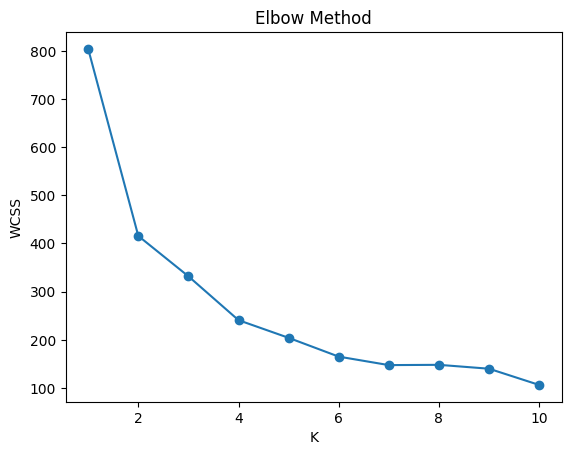

In [77]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()

- Finding Optimal Value of k

In [78]:
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(x)
    print(f"K:{k} -> {silhouette_score(x, labels):.3f}")

K:2 -> 0.397
K:3 -> 0.317
K:4 -> 0.358
K:5 -> 0.373
K:6 -> 0.368
K:7 -> 0.385
K:8 -> 0.404
K:9 -> 0.416
K:10 -> 0.434


Selecting K=4 as optimal number of cluster

In [79]:
best_k=4

In [80]:
df_model.to_csv("dataset(post).csv",index=False)
print("Phase 1 Completed")

Phase 1 Completed


Applying KMeans

In [81]:
kmeans=KMeans(n_clusters=4,random_state=42)
df_model["Cluster"]=kmeans.fit_predict(x)

Clustering

In [82]:
df_model.groupby("Cluster")[["Annual_Spending", "Purchase_Frequency"]].mean()

,Annual_Spending,Purchase_Frequency
Cluster,,
0,13.098434,3.721706
1,12.965917,2.984680
2,11.780580,3.294279
3,14.025907,3.727423


In [83]:
for i in range(4):
    cluster=df_model[df_model["Cluster"]==i]
    avg_sp=cluster["Annual_Spending"].mean()
    avg_fq =cluster["Purchase_Frequency"].mean()

    print(f"\n{'++'*4}\nCluster {i}")
    print("Avg Spending:", round(avg_sp, 2))
    print("Avg Frequency:", round(avg_fq, 2))

    if avg_sp > df_model["Annual_Spending"].mean() and avg_fq > df_model["Purchase_Frequency"].mean():
        print("Type: High-Value Loyal Customers")
    elif avg_sp > df_model["Annual_Spending"].mean():
        print("Type: High Spenders (Occasional)")
    elif avg_fq > df_model["Purchase_Frequency"].mean():
        print("Type: Frequent Budget Customers")
    else:
        print("Type: Low Engagement Customers")


++++++++
Cluster 0
Avg Spending: 13.1
Avg Frequency: 3.72
Type: High-Value Loyal Customers

++++++++
Cluster 1
Avg Spending: 12.97
Avg Frequency: 2.98
Type: Low Engagement Customers

++++++++
Cluster 2
Avg Spending: 11.78
Avg Frequency: 3.29
Type: Low Engagement Customers

++++++++
Cluster 3
Avg Spending: 14.03
Avg Frequency: 3.73
Type: High-Value Loyal Customers


**Customer Profiling**

In [84]:
profile=df_model.groupby("Cluster").agg({"Annual_Spending": "mean","Purchase_Frequency": "mean","Annual_Income": "mean"}).round(2)
profile

,Annual_Spending,Purchase_Frequency,Annual_Income
Cluster,,,
0,13.10,3.72,14.28
1,12.97,2.98,14.12
2,11.78,3.29,13.23
3,14.03,3.73,15.33


**Customer Segmentation Graph**

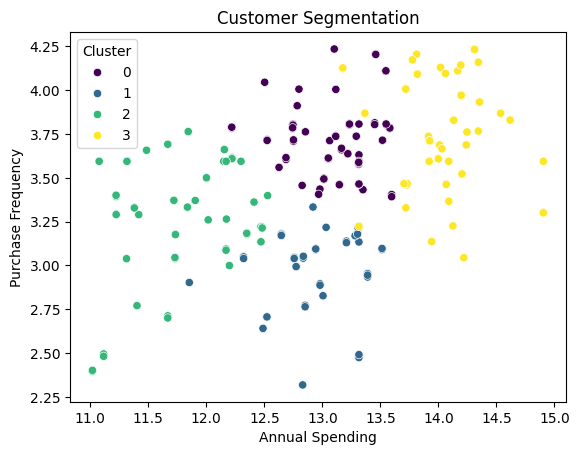

In [85]:
sb.scatterplot(x=df_model["Annual_Spending"],y=df_model["Purchase_Frequency"],hue=df_model["Cluster"],palette="viridis")
plt.title("Customer Segmentation")
plt.xlabel("Annual Spending")
plt.ylabel("Purchase Frequency")
plt.show()

Centroid Graph

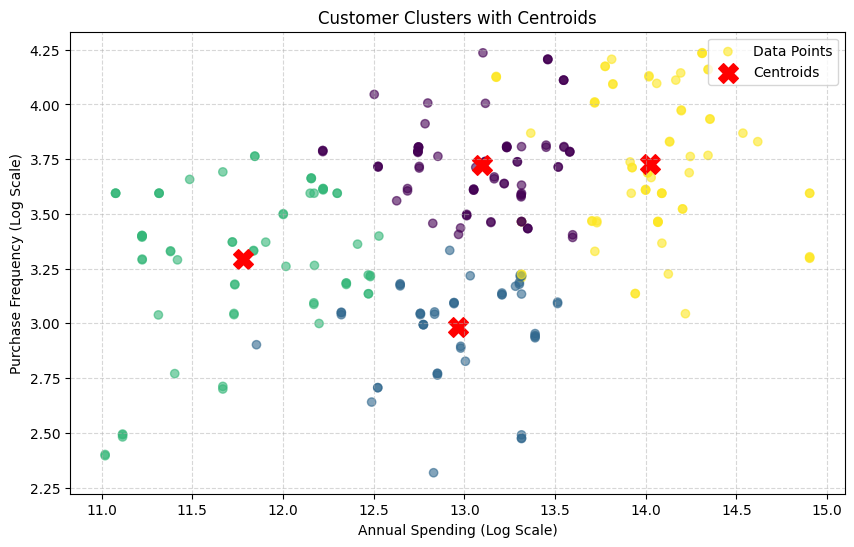

In [86]:
centroids = ss.inverse_transform(kmeans.cluster_centers_)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_model['Annual_Spending'], df_model['Purchase_Frequency'], c=df_model['Cluster'], cmap='viridis', alpha=0.6, label='Data Points')
plt.scatter(centroids[:, 1], centroids[:, 2], c='red', marker='X', s=200, label='Centroids')
plt.title("Customer Clusters with Centroids")
plt.xlabel("Annual Spending (Log Scale)")
plt.ylabel("Purchase Frequency (Log Scale)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Income Vs Spending

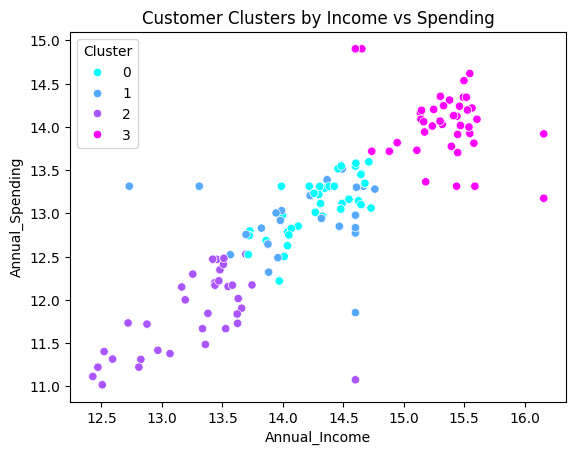

In [87]:
sb.scatterplot(x="Annual_Income",y="Annual_Spending",hue="Cluster",data=df_model,palette="cool")
plt.title("Customer Clusters by Income vs Spending")
plt.show()